# Математические открытки

## Розочка

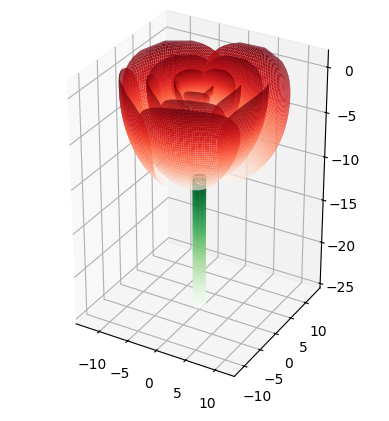

In [3]:
from matplotlib import pyplot as plt
from math import sqrt, pi, cos, sin
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

t_grid = np.linspace(-1 - sqrt(7), -1 + sqrt(7), 50)
s_grid = np.linspace(-1, 1, 50)
T, S = np.meshgrid(t_grid, s_grid)
theta_fun = lambda t, s: 0.2 * pi * (t + 1 + sqrt(7)) / sqrt(7) - 0.4 * pi + 0.1
phi_fun = lambda t, s: pi * s / (4 * sqrt(2)) * sqrt(max(2 - t ** 2 / abs(t - 3), 0))
for k in range(1, 16):
  phi0 = 0.4 * pi * k
  r = 14 - 0.8 * k
  x_fun = lambda t, s: r * cos(phi0 + phi_fun(t, s)) * cos(theta_fun(t, s))
  y_fun = lambda t, s: r * sin(phi0 + phi_fun(t, s)) * cos(theta_fun(t, s))
  z_fun = lambda t, s: r * sin(theta_fun(t, s))
  X = np.array(list(map(x_fun, T.flatten(), S.flatten()))).reshape((50, 50))
  Y = np.array(list(map(y_fun, T.flatten(), S.flatten()))).reshape((50, 50))
  Z = np.array(list(map(z_fun, T.flatten(), S.flatten()))).reshape((50, 50))
  ax.plot_surface(X, Y, Z, cmap='Reds')
z = np.linspace(-25, -10, 50)
p = np.linspace(0, 2 * pi, 50)
Z, P = np.meshgrid(z, p)
X = np.cos(P)
Y = np.sin(P)
ax.plot_surface(X, Y, Z, cmap='Greens')
ax.set_box_aspect(aspect=(1, 1, 1.5))
plt.show()

*Задание:* Оптимизируйте следующий код.

<iframe src="https://trinket.io/embed/python3/fbb7581526" width="100%" height="356" frameborder="0" marginwidth="0" marginheight="0" allowfullscreen></iframe>

## Ёлочка

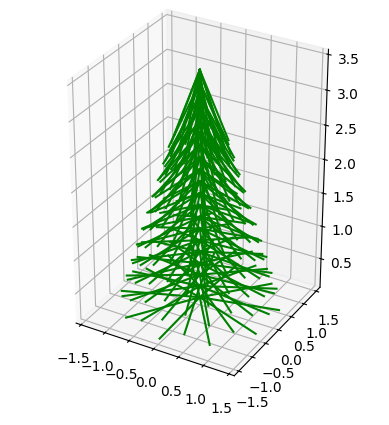

In [1]:
from matplotlib import pyplot as plt
from math import pi, cos, sin

def plot_segment(x1, y1, z1, x2, y2, z2):
  plt.plot([x1, x2], [y1, y2], [z1, z2], 'g', linewidth=1.5)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

n = 20
m = 10
dr = [0.5 + i / n for i in range(n)]
dz = [-1 + i / n for i in range(n)]
z = [3.5 * (1 - i / n) for i in range(n)]
phi = [[2 * pi * (i / n + j / m) for j in range(m)] for i in range(n)]
dx = [[dr[i] * cos(phi[i][j]) for j in range(m)] for i in range(n)]
dy = [[dr[i] * sin(phi[i][j]) for j in range(m)] for i in range(n)]

for i in range(n):
  for j in range(m):
    plot_segment(0, 0, z[i], dx[i][j], dy[i][j], z[i] + dz[i])

ax.set_box_aspect(aspect=(1, 1, 1.5))
plt.show()

*Задание:* Добавьте отрисовку шаров на ветках, чтобы украсить ёлочку.

## К 8 Марта

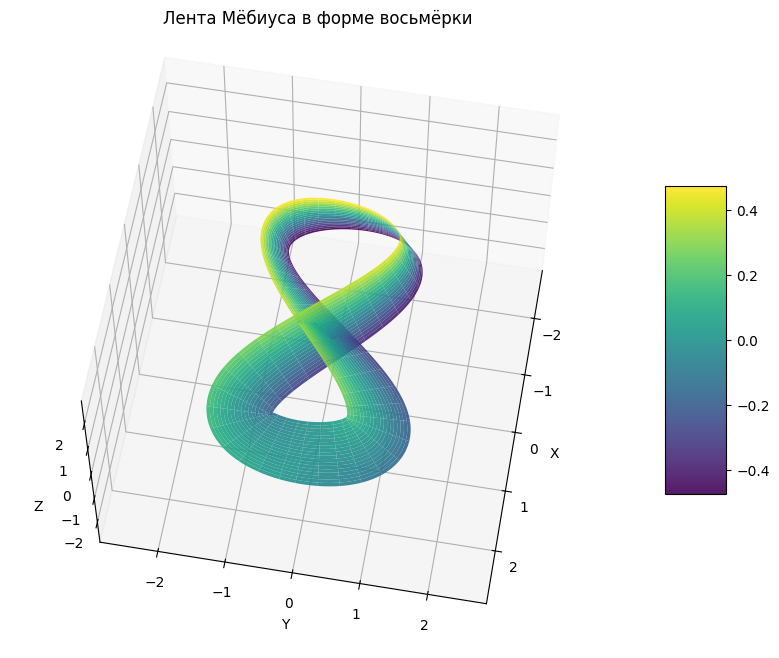

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Параметры формы
a = 2.0          # полуширина восьмёрки по оси X
b = 1.0          # амплитуда восьмёрки по оси Y
width = 0.5      # ширина ленты
nu = 200         # число точек вдоль ленты (параметр u)
nv = 20          # число точек поперёк ленты (параметр v)

# Сетка параметров
u = np.linspace(0, 2 * np.pi, nu)
v = np.linspace(-width, width, nv)
u, v = np.meshgrid(u, v)

# Центральная кривая в форме восьмёрки (лемниската)
X0 = a * np.cos(u)
Y0 = b * np.sin(2 * u)
Z0 = np.zeros_like(u)

# Производные центральной кривой (касательный вектор)
X0p = -a * np.sin(u)
Y0p = 2 * b * np.cos(2 * u)

# Длина касательной (защита от деления на ноль)
Tlen = np.sqrt(X0p**2 + Y0p**2)
Tlen = np.where(Tlen < 1e-12, 1e-12, Tlen)

# Единичный вектор, перпендикулярный касательной в плоскости XY (горизонтальная нормаль)
Nx = -Y0p / Tlen
Ny =  X0p / Tlen
Nz = np.zeros_like(Nx)

# Поворот вектора ширины на половину угла u (создаёт перекручивание)
cos_half = np.cos(u / 2)
sin_half = np.sin(u / 2)

# Вектор ширины (комбинация горизонтальной нормали и вертикального направления)
Wx = cos_half * Nx
Wy = cos_half * Ny
Wz = sin_half * np.ones_like(u)   # вертикальная компонента

# Координаты поверхности
X = X0 + v * Wx
Y = Y0 + v * Wy
Z = Z0 + v * Wz

# Построение графика
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9,
                       linewidth=0, antialiased=True)

# Настройка осей и заголовка
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Лента Мёбиуса в форме восьмёрки')

# Равный масштаб для всех осей
max_range = max(np.abs(X).max(), np.abs(Y).max(), np.abs(Z).max()) * 1.1
ax.set_xlim(-max_range, max_range)
ax.set_ylim(-max_range, max_range)
ax.set_zlim(-max_range, max_range)

# угол обзора
ax.view_init(elev=60, azim=10)

# Цветовая шкала
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()